# Financial Indicators vs World Happiness: A Cross-Country Analysis

**Objective:** This notebok investigates how a country's financial and economic conditions relate to self-reported happiness, using the World Happiness Report (2019–2025) combined with World Bank economic indicators (GDP per capita, inflation, unemployment, and income inequality via the Gini index).

**Data sources:**
- World Happiness Report (worldhappiness.report) — happiness scores and the Report's own explanatory factors (GDP, social support, life expectancy, freedom, generosity, corruption) for ~150 countries, 2019–2025.
- World Bank Open Data API — GDP per capita, inflation, unemployment, and Gini index for the same countries and years.

**Structure:** The notebook follows a full pipeline: sourcing and cleaning the happiness data, sourcing and cleaning the World Bank data (including reconciling inconsistent country naming between sources), merging the two, then exploring and visualising the relationships between them.

### **Imports**

In [66]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from difflib import get_close_matches
import pycountry_convert as pc

### Getting the World Happiness Data 

1. download the files off the web
2. add them into a list 
3. convert the list into a pandas database

In [67]:
years = {
    2026: "Happiness_Data/WHR26_Data_Figure_2.1.xlsx",
    2025: "Happiness_Data/WHR25_Data_Figure_2.1v3.xlsx",
    2024: "Happiness_Data/WHR24_Data_Figure_2.1.xls",
    2023: "Happiness_Data/WHR23_Data_Figure_2.1.xls",
    2022: "Happiness_Data/WHR22_Data_Figure_2.1.xls",
}

happiness_years = []

for year, path in years.items():
    df = pd.read_excel(path)
    df['report_year'] = year
    happiness_years.append(df)

happiness_df = pd.concat(happiness_years, ignore_index=True)
happiness_df.head()


,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,...,Generosity,Perceptions of corruption,Ladder score in Dystopia,RANK,Country,Happiness score,Whisker-high,Whisker-low,Dystopia (1.83) + residual,Explained by: GDP per capita
0,2025.0,1.0,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025.0,2.0,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025.0,3.0,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025.0,4.0,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025.0,5.0,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Cleaning

1. Check for duplicates

2. From the head output its clear there are lots of null values, but lets chck how many and ho we can deal with them 

In [68]:
if happiness_df.duplicated().sum() == 0:
    print("No Duplicates")
else:
    print("There are Duplicates!")

happiness_df.isnull().sum()

No Duplicates


Year                                           427
Rank                                           427
Country name                                   147
Life evaluation (3-year average)               427
Lower whisker                                 2615
Upper whisker                                 2615
Explained by: Log GDP per capita              2344
Explained by: Social support                  2198
Explained by: Healthy life expectancy         2204
Explained by: Freedom to make life choices    2201
Explained by: Generosity                      2198
Explained by: Perceptions of corruption       2200
Dystopia + residual                           2355
report_year                                      0
Ladder score                                  4232
upperwhisker                                  4232
lowerwhisker                                  4232
Standard error of ladder score                4375
Logged GDP per capita                         4375
Social support                 

### Null value Investigation 

1. More null values than expected from a reliable source.

2. The null sums are consistant which makes me think its coulumn namings being off between excel sheets 

In [69]:
for year, path in years.items():
    df = pd.read_excel(path)
    print(year, list(df.columns))

2026 ['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
2025 ['Year', 'Rank', 'Country name', 'Life evaluation (3-year average)', 'Lower whisker', 'Upper whisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
2024 ['Country name', 'Ladder score', 'upperwhisker', 'lowerwhisker', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of cor

1. It looks like we have lots of different headers in here which confirms what I was thinking 

2. Also, we have a year header in 2026 and 2025 meaning they could contain multiple years and therefore significnatly increse null value 

print()

In [70]:
df_2026 = pd.read_excel(years[2026])
df_2026['Year'].unique()

array([2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015,
       2014, 2012, 2011])

So we actually only needs the 2026 data as it contains all years from 2011

In [71]:
df_2026.isnull().sum()

Year                                             0
Rank                                             0
Country name                                     0
Life evaluation (3-year average)                 0
Lower whisker                                 1094
Upper whisker                                 1094
Explained by: Log GDP per capita              1097
Explained by: Social support                  1097
Explained by: Healthy life expectancy         1100
Explained by: Freedom to make life choices    1099
Explained by: Generosity                      1097
Explained by: Perceptions of corruption       1098
Dystopia + residual                           1103
dtype: int64

Still lots of *null* values but there could be misisng columns for certain years 

In [72]:
def count_nulls(series):
    return series.isnull().sum()

df_2026.groupby('Year')['Explained by: Log GDP per capita'].apply(count_nulls)

Year
2011    156
2012    156
2014    158
2015    157
2016    155
2017    156
2018    156
2019      0
2020      0
2021      0
2022      0
2023      3
2024      0
2025      0
Name: Explained by: Log GDP per capita, dtype: int64

I'm going to drop pre 2019 as its missing alot of data and we will still have 7 years worth of data 

In [73]:
df_2026 = df_2026[df_2026['Year'] >= 2019]
df_2026.isnull().sum()

Year                                          0
Rank                                          0
Country name                                  0
Life evaluation (3-year average)              0
Lower whisker                                 0
Upper whisker                                 0
Explained by: Log GDP per capita              3
Explained by: Social support                  3
Explained by: Healthy life expectancy         6
Explained by: Freedom to make life choices    5
Explained by: Generosity                      3
Explained by: Perceptions of corruption       4
Dystopia + residual                           9
dtype: int64

Setting up some Naming convetions as the given ones arent useful

In [74]:
df_2026 = df_2026.rename(columns={
    'Country name': 'country',
    'Life evaluation (3-year average)': 'happiness_score',
    'Year': 'report_year',
    'Rank': 'rank',
    'Lower whisker': 'whisker_low',
    'Upper whisker': 'whisker_high',
    'Explained by: Log GDP per capita': 'gdp_explained',
    'Explained by: Social support': 'social_support_explained',
    'Explained by: Healthy life expectancy': 'life_expectancy_explained',
    'Explained by: Freedom to make life choices': 'freedom_explained',
    'Explained by: Generosity': 'generosity_explained',
    'Explained by: Perceptions of corruption': 'corruption_explained',
    'Dystopia + residual': 'dystopia_residual',
})


### left over null values 

- These are not interpolatable as most of these countires contain less than one data point and therefore it would just be modal value

- We also couldn't do it by rank as their individual data points aren't necesarily a causation for their rank and it would be inaccurate. 

- Some values are also just 0, and this could be sewing the data if there are lots of them

In [75]:
(df_2026.values == 0).sum()



42

So in total we have an insignifaicnt number of potential errors to actually affect the data set 

## Getting the World Banking Data

- I'll use the rest API's that are publically availible 
- See how it is given back to me 
- structure it from there 


In [76]:
import requests
import json 
import pprint


URL = {
    "gdp_per_capita": "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&date=2019:2025&per_page=20000",
    "inflation": "https://api.worldbank.org/v2/country/all/indicator/FP.CPI.TOTL.ZG?format=json&date=2019:2025&per_page=20000",
    "unemployment": "https://api.worldbank.org/v2/country/all/indicator/SL.UEM.TOTL.ZS?format=json&date=2019:2025&per_page=20000",
    "gini_index": "https://api.worldbank.org/v2/country/all/indicator/SI.POV.GINI?format=json&date=2019:2025&per_page=20000"
}

#Lets see whats it returns the data as 
test = requests.get(URL['gdp_per_capita'])
data = test.json()
pprint.pprint(data[1][:2])

[{'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2025',
  'decimal': 1,
  'indicator': {'id': 'NY.GDP.PCAP.CD',
                'value': 'GDP per capita (current US$)'},
  'obs_status': '',
  'unit': '',
  'value': 1722.38561960923},
 {'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2024',
  'decimal': 1,
  'indicator': {'id': 'NY.GDP.PCAP.CD',
                'value': 'GDP per capita (current US$)'},
  'obs_status': '',
  'unit': '',
  'value': 1628.22728900442}]


In [77]:
indicator_data = []
for indicator, url in URL.items():
    reponse = requests.get(url)
    data = reponse.json()[1]

# Make this into a dictionary in lists 
    records = []
    for entry in data:
        records.append({
            'country': entry['country']['value'],
            'report_year': int(entry['date']),
            indicator: entry['value'],
        })
    df = pd.DataFrame(records)
    indicator_data.append(df)
indicator_data[0]


,country,report_year,gdp_per_capita
0,Africa Eastern and Southern,2025,1722.385620
1,Africa Eastern and Southern,2024,1628.227289
2,Africa Eastern and Southern,2023,1571.132704
3,Africa Eastern and Southern,2022,1675.902524
4,Africa Eastern and Southern,2021,1560.894626
...,...,...,...
1850,Zimbabwe,2023,2195.225020
1851,Zimbabwe,2022,2536.401971
1852,Zimbabwe,2021,2613.616741
1853,Zimbabwe,2020,2059.637040


### Data Reconciliation to allow a left join with happiness data

1. We need countries to match 

- currently we have lots of random countries that will need reconciling to match the countries we have in happiness data so we can join the two tables and compare 

- fastest was to do this is going to be AI...

In [78]:
indicator_data[0]['country'].unique()

array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD countries)', 'Euro area',
       'Europe & Central Asia',
       'Europe & Central Asia (excluding high income)',
       'Europe & Central Asia (IDA & IBRD countries)', 'European Union',
       'Heavily indebted poor countries (HIPC)', 'High income',
       'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only',
       'IDA total', 'Late-demographic dividend',
       'Latin America & Caribbean',
       'Latin America & Caribbean (excluding high income)',
       'Latin America & the Caribbean (IDA & IBRD countries)',
       'Least developed countries: UN classification',
       'Low & middle income', 'Low income', 'Lower middle income',
       'Middle East, North Africa, Afghanist

In [79]:
df_2026['country'].unique()

array(['Finland', 'Iceland', 'Denmark', 'Costa Rica', 'Sweden', 'Norway',
       'Netherlands', 'Israel', 'Luxembourg', 'Switzerland',
       'New Zealand', 'Mexico', 'Ireland', 'Belgium', 'Australia',
       'Kosovo', 'Germany', 'Slovenia', 'Austria', 'Czechia',
       'United Arab Emirates', 'Saudi Arabia', 'United States', 'Poland',
       'Canada', 'Taiwan Province of China', 'Belize', 'Lithuania',
       'United Kingdom', 'Serbia', 'Uruguay', 'Brazil', 'Kazakhstan',
       'Romania', 'France', 'Singapore', 'El Salvador', 'Italy', 'Panama',
       'Kuwait', 'Spain', 'Guatemala', 'Malta', 'Argentina', 'Viet Nam',
       'Estonia', 'Bosnia and Herzegovina', 'Latvia', 'Jamaica', 'Chile',
       'Nicaragua', 'Thailand', 'Uzbekistan', 'Slovakia', 'Bahrain',
       'Philippines', 'Paraguay', 'Oman', 'Ecuador', 'Montenegro',
       'Japan', 'Cyprus', 'Honduras', 'Dominican Republic', 'China',
       'Kyrgyzstan', 'Republic of Korea', 'Colombia', 'Portugal',
       'Croatia', 'Malaysia', '

In [80]:
wb_countries = set(indicator_data[0]['country'].unique())
happiness_countries = set(df_2026['country'].unique())

only_in_wb = wb_countries - happiness_countries
print(f"{len(only_in_wb)} World Bank names have no exact match in the happiness data")

127 World Bank names have no exact match in the happiness data


In [81]:
suggestions = [
    {'wb_name': name, 'suggested_match': (get_close_matches(name, happiness_countries, n=1, cutoff=0.6) or [None])[0]}
    for name in only_in_wb
]
suggestions_df = pd.DataFrame(suggestions)
suggestions_df[suggestions_df['suggested_match'].notna()].sort_values('wb_name')

,wb_name,suggested_match
50,Angola,Mongolia
91,"Congo, Rep.",Congo
80,Cote d'Ivoire,Côte d’Ivoire
96,Dominica,Romania
60,"Gambia, The",Gambia
84,Greenland,Ireland
105,Grenada,Canada
17,Guam,Guatemala
92,Guinea-Bissau,Guinea
6,Guyana,Ghana


In [82]:
suggestions_df[suggestions_df['suggested_match'].isna()].sort_values('wb_name')

,wb_name,suggested_match
61,Africa Eastern and Southern,None
99,Africa Western and Central,None
41,American Samoa,None
24,Andorra,None
49,Antigua and Barbuda,None
...,...,...
86,Upper middle income,None
73,Vanuatu,None
11,Virgin Islands (U.S.),None
5,West Bank and Gaza,None


In [83]:
country_rename_map = {
    'West Bank and Gaza': 'State of Palestine',
    'Congo, Dem. Rep.': 'DR Congo',
    'Congo, Rep.': 'Congo',
    'Somalia, Fed. Rep.': 'Somalia',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Egypt, Arab Rep.': 'Egypt',
    'Korea, Rep.': 'Republic of Korea',
    'Iran, Islamic Rep.': 'Iran',
    'Gambia, The': 'Gambia',
    'Hong Kong SAR, China': 'Hong Kong SAR of China',
    "Cote d'Ivoire": 'C\u00f4te d\u2019Ivoire',
    'Yemen, Rep.': 'Yemen',
    'Slovak Republic': 'Slovakia',
    'Venezuela, RB': 'Venezuela',
    'Turkiye': 'T\u00fcrkiye',
}

for df in indicator_data:
    df['country'] = df['country'].replace(country_rename_map)

still_unmatched = (set(indicator_data[0]['country'].unique()) - happiness_countries) & only_in_wb
print("Still unmatched country names:", len(still_unmatched))

Still unmatched country names: 112


The un-matched country names arent actual countries they are region/income group aggreagtes.

### Merge the data sets

In [84]:
wb_data = indicator_data[0].merge(indicator_data[1], on=['country', 'report_year'], how='outer')
wb_data = wb_data.merge(indicator_data[2], on=['country', 'report_year'], how='outer')
wb_data = wb_data.merge(indicator_data[3], on=['country', 'report_year'], how='outer')

combined = df_2026.merge(wb_data, on=['country', 'report_year'], how='left')
combined.isnull().sum()

report_year                    0
rank                           0
country                        0
happiness_score                0
whisker_low                    0
whisker_high                   0
gdp_explained                  3
social_support_explained       3
life_expectancy_explained      6
freedom_explained              5
generosity_explained           3
corruption_explained           4
dystopia_residual              9
gdp_per_capita                29
inflation                     68
unemployment                  35
gini_index                   653
dtype: int64

## Merged Missing Data


Gini showing lots of null values but this expected as they only run this survey every foru years at best 

However, the gdp_per_capita having missing values isn't great as this is done yearly.

-> so this needs looking into 

In [85]:
combined[combined['gdp_per_capita'].isnull()]['country'].value_counts()

country
Taiwan Province of China    7
Republic of Moldova         7
Yemen                       6
North Cyprus                3
Swaziland                   2
United Arab Emirates        1
Lebanon                     1
Afghanistan                 1
South Sudan                 1
Name: count, dtype: int64

Three countries have essentially no World Bank coverage across the whole period. With most columns missing for every row, they add nothing to a financial-indicators analysis, so they're dropped.

In [86]:
countries_to_drop = ['Taiwan Province of China', 'Republic of Moldova', 'Yemen']
combined = combined[~combined['country'].isin(countries_to_drop)].copy()
print(f"Final dataset: {len(combined)} rows, {combined['country'].nunique()} countries, {combined['report_year'].nunique()} years")

Final dataset: 1002 rows, 154 countries, 7 years


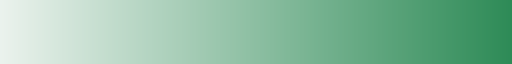

In [87]:
sns.light_palette("seagreen", as_cmap=True)

# Generic look at correlations

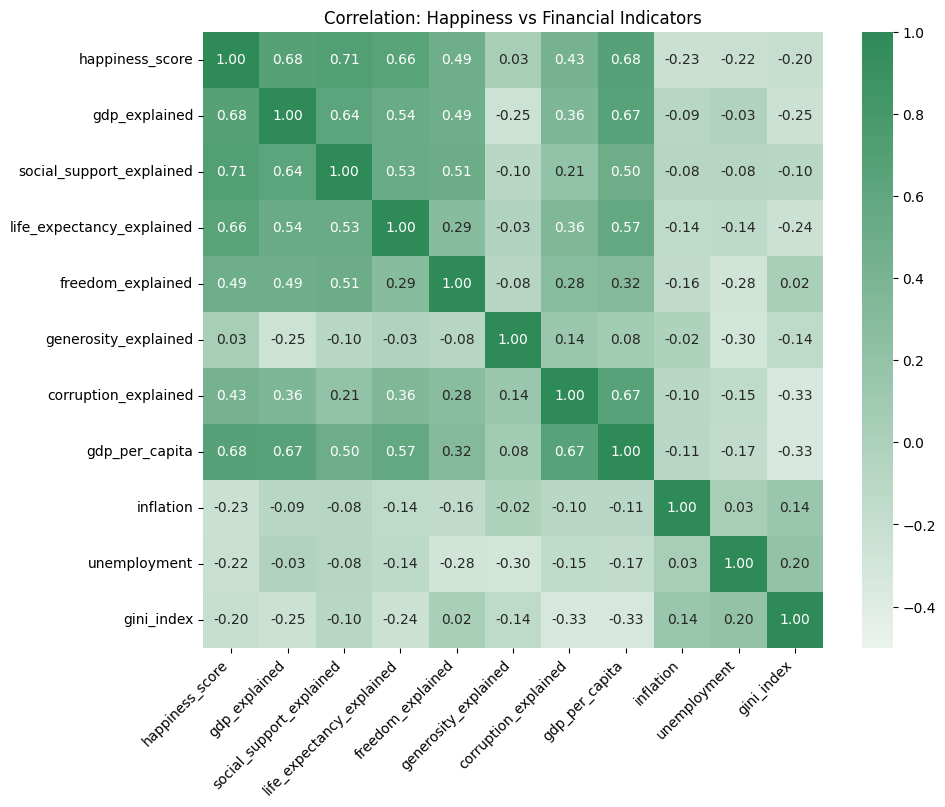

In [88]:
green_cmap = sns.light_palette("seagreen", as_cmap=True)

corr_cols = ['happiness_score', 'gdp_explained', 'social_support_explained',
             'life_expectancy_explained', 'freedom_explained', 'generosity_explained',
             'corruption_explained', 'gdp_per_capita', 'inflation', 'unemployment', 'gini_index']


plt.figure(figsize=(10, 8))
sns.heatmap(combined[corr_cols].corr(), annot=True, cmap=green_cmap, fmt='.2f', vmin=-0.5, vmax=1)
plt.xticks(rotation=45, ha='right')
plt.title('Correlation: Happiness vs Financial Indicators')
plt.show()

# Insights to Explore / Hypotheses

## From the correlation table, there are a few key relationships to explore:

### As Expected:
1. GDP / happiness
    - *Richer people are generally happier.*
2. Social support / happiness
    - *People who feel supported are happier.*
3. Life expectancy / happiness
    - *People who are healthier are happier.*

### Unexpected:
1. Unemployment / social support
    - I assumed unemployment would relate to people not feeling supported.
    - Actually, it shows that economic security and social connectedness are largely independent of each other.

2. Generosity_explained / anything
    - I assumed happier and/or wealthier countries would have more generous people.
    - Against GDP-explained, there is a negative relationship — showing that the richer a country is perceived to be, the less generous it is also perceived to be.
    - However, generosity vs. unemployment goes in the direction I'd expect: if you don't have a job, you're less likely to donate to charity.

3. Corruption_explained / Gini index
    - I thought these two would be highly correlated, since corruption generally implies more inequality.
    - I think this could be an example of the difference between quantitative and qualitative data collection — "corrupt" money may not appear in quantitative measures, but if you're living there, it's very clear qualitatively.

### Comparisons to Explore Further:
1. Happiness score's relationship to inflation, unemployment, and the Gini index are all negative.
    - They're weak but not zero, and all point in the same direction.
    - This suggests that higher inflation, unemployment, and inequality generally line up with lower happiness.
    - This is expected, but I'd be curious to look at countries that don't fit this trend.

2. GDP per capita's relationship with happiness is much stronger than the relationships of inflation, unemployment, and inequality.
    - This suggests that overall national wealth matters more to reported happiness than short-term economic conditions such as inflation, unemployment, or income distribution.
    - I was more skeptical about the Gini coefficient, as income inequality tends to be "stickier" (slower to change) than unemployment or inflation.

## Some Extra points to Calculate

1. Grouping contries by continent/region

2. Income tiers 

3. Rank movements over teh 7 years 

### 1. Continent/ Region grouping

In [89]:
def get_continent(country_name):
    try:
        code_ = pc.country_name_to_country_alpha2(country_name)
        return pc.convert_continent_code_to_continent_name(pc.country_alpha2_to_continent_code(code_))
    except Exception:
        return None

combined['region'] = combined['country'].apply(get_continent)

manual_region_map = {
    'Kosovo': 'Europe', 'Republic of Korea': 'Asia', 'Hong Kong SAR of China': 'Asia',
    'Lao PDR': 'Asia', 'C\u00f4te d\u2019Ivoire': 'Africa', 'State of Palestine': 'Asia',
    'DR Congo': 'Africa', 'North Cyprus': 'Europe',
}
combined['region'] = combined['region'].fillna(combined['country'].map(manual_region_map))
combined['region'].isnull().sum()

0

### 2. Income Tiers

In [90]:
combined['income_tier'] = pd.qcut(
    combined['gdp_per_capita'], q=4,
    labels=['Low income', 'Lower-middle', 'Upper-middle', 'High income']
)
combined[['country', 'report_year', 'gdp_per_capita', 'income_tier']].sample(5, random_state=1)

,country,report_year,gdp_per_capita,income_tier
971,Niger,2019,541.265820,Low income
770,Latvia,2020,17564.232155,Upper-middle
325,Romania,2023,18244.418688,Upper-middle
378,Algeria,2023,5370.477235,Lower-middle
507,Bosnia and Herzegovina,2022,7655.594210,Upper-middle


### 3. Ranked Movement 

In [91]:
rank_pivot = combined.pivot_table(index='country', columns='report_year', values='rank')
rank_change = (rank_pivot[2019] - rank_pivot[2025]).dropna().sort_values(ascending=False)
rank_change.name = 'rank_change'
print("Biggest improvers (rank went up, i.e. happier):")
print(rank_change.head(5))
print("\nBiggest decliners (rank went down):")
print(rank_change.tail(5))

Biggest improvers (rank went up, i.e. happier):
country
Viet Nam      38.0
Serbia        34.0
China         29.0
India         28.0
Mozambique    27.0
Name: rank_change, dtype: float64

Biggest decliners (rank went down):
country
Lebanon               -30.0
Trinidad and Tobago   -34.0
Congo                 -34.0
Pakistan              -38.0
Benin                 -38.0
Name: rank_change, dtype: float64


# Data Visulisation

## 1. GDP Vs Happiness Scores

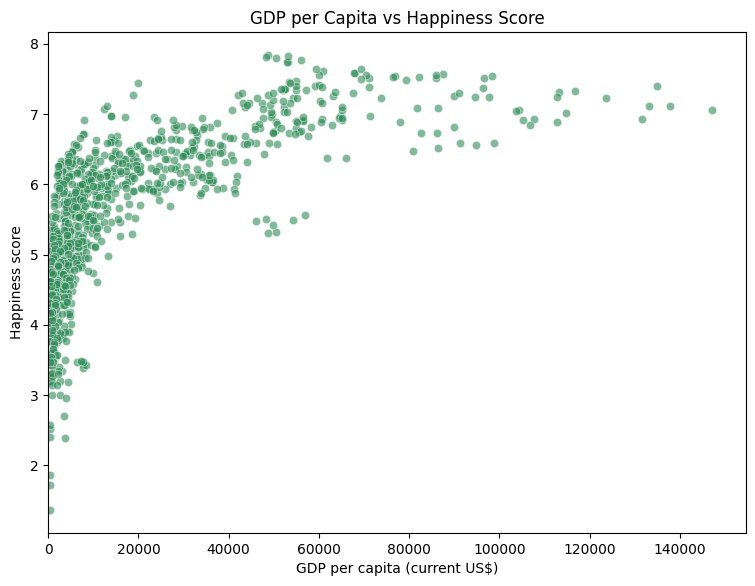

In [92]:
plt.figure(figsize=(9, 6.5))
sns.scatterplot(data=combined, x='gdp_per_capita', y='happiness_score', alpha=0.6, color='seagreen')
plt.title('GDP per Capita vs Happiness Score')
plt.xlabel('GDP per capita (current US$)')
plt.ylabel('Happiness score')
plt.xlim(0, None)
plt.show()

There's a clear relationship, but it's not a straight line: happiness rises quickly with GDP between roughly \$0-20k per capita, then largely plateaus - beyond that point, wealth alone stops predicting extra happiness.

There are also clear outliers - some countries sit far below where their GDP alone would predict. One cluster around \$45-65k GDP but only ~5.0-5.6 happiness:

In [93]:
combined[(combined['gdp_per_capita'].between(45000, 65000)) &
         (combined['happiness_score'].between(4.8, 5.6))][['country', 'report_year', 'happiness_score', 'gdp_per_capita']]

,country,report_year,happiness_score,gdp_per_capita
89,Hong Kong SAR of China,2025,5.5690,56983.066306
234,Hong Kong SAR of China,2024,5.4910,54274.754777
379,Hong Kong SAR of China,2023,5.3160,50525.111931
518,Hong Kong SAR of China,2022,5.3080,48825.027228
654,Hong Kong SAR of China,2021,5.4250,49770.564237
796,Hong Kong SAR of China,2020,5.4770,46109.229995
946,Hong Kong SAR of China,2019,5.5104,48359.001195


## Hong Kong Cluster

Looking into this it's consistent with the 2019-2020 political unrest, the national security law, and strict COVID policies over this window - a case where wealth clearly isn't translating into happiness, so it's reasonable to treat it as a context-driven outlier rather than a flaw in the GDP/happiness relationship.

## Money = Happiness

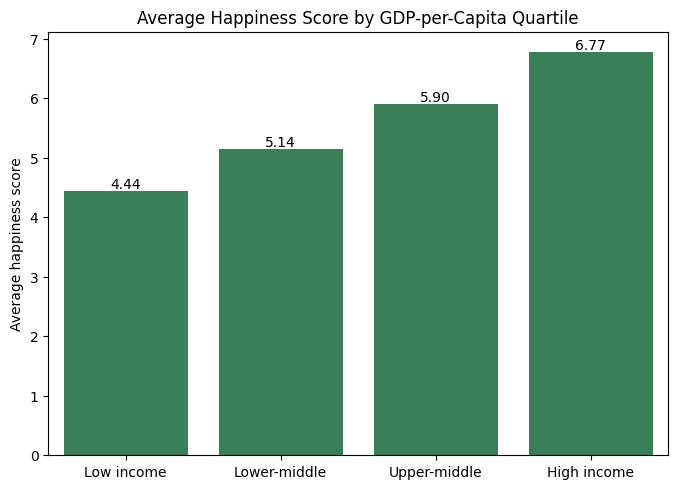

In [94]:
tier_order = ['Low income', 'Lower-middle', 'Upper-middle', 'High income']
plt.figure(figsize=(8, 5.5))
ax = sns.barplot(data=combined, x='income_tier', y='happiness_score', order=tier_order, color='seagreen', errorbar=None)
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.title('Average Happiness Score by GDP-per-Capita Quartile')
plt.xlabel('')
plt.ylabel('Average happiness score')
plt.show()

 Clearly, More money = more happiness in general !

## Happiness Distribution by region 

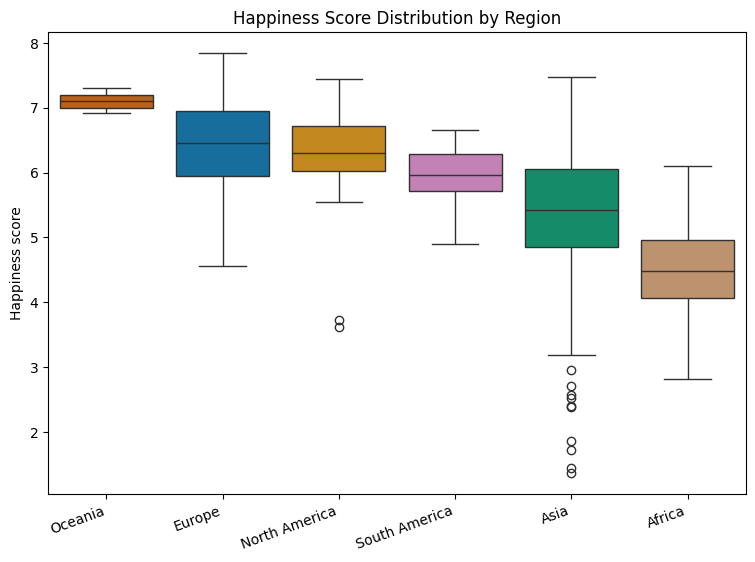

In [95]:
region_order = combined.groupby('region')['happiness_score'].median().sort_values(ascending=False).index
plt.figure(figsize=(9, 6))
sns.boxplot(data=combined, x='region', y='happiness_score', order=region_order,
            hue='region', palette='colorblind', legend=False)
plt.title('Happiness Score Distribution by Region')
plt.xlabel('')
plt.ylabel('Happiness score')
plt.xticks(rotation=20, ha='right')
plt.show()

## Regional comparison of Wealth Vs Happiness

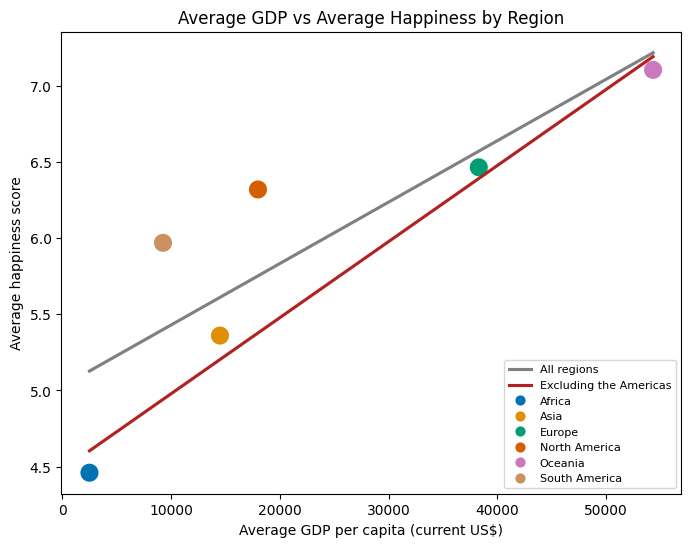

In [96]:
region_avg = combined.groupby('region')[['gdp_per_capita', 'happiness_score']].mean().reset_index()
region_avg_no_americas = region_avg[~region_avg['region'].isin(['North America', 'South America'])]

plt.figure(figsize=(8, 6))
sns.regplot(data=region_avg, x='gdp_per_capita', y='happiness_score', scatter=False, color='gray', ci=None, label='All regions')
sns.regplot(data=region_avg_no_americas, x='gdp_per_capita', y='happiness_score', scatter=False, color='firebrick', ci=None, label='Excluding the Americas')
sns.scatterplot(data=region_avg, x='gdp_per_capita', y='happiness_score', hue='region', palette='colorblind', s=200)
plt.legend(loc='lower right', fontsize=8, markerscale=0.6)
plt.title('Average GDP vs Average Happiness by Region')
plt.xlabel('Average GDP per capita (current US$)')
plt.ylabel('Average happiness score')
plt.show()

The Americas are the clear outlier region: both North and South America sit well above the wealth-implied happiness trend line, while removing them tightens the relationship considerably for the rest of the world. This suggests non-financial, culturally-linked factors (social ties, optimism) matter more in the Americas than income alone would predict.

## Biggest Happiness Rank Movers, 2019-2025 

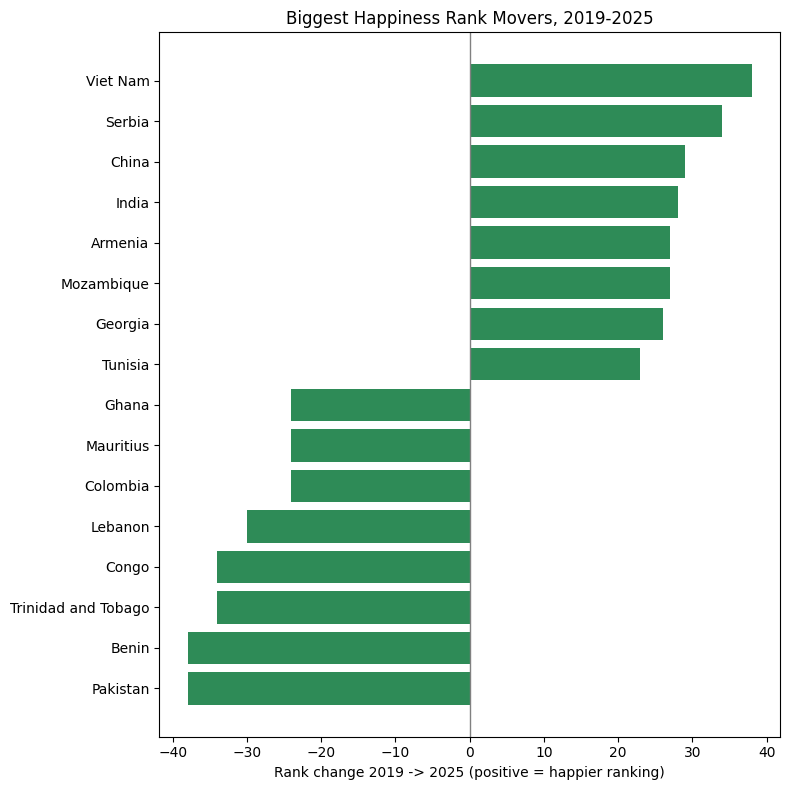

In [101]:
movers = pd.concat([rank_change.head(8), rank_change.tail(8)]).sort_values()
plt.figure(figsize=(8, 8))
plt.barh(movers.index, movers.values, color='seagreen')
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel('Rank change 2019 -> 2025 (positive = happier ranking)')
plt.title('Biggest Happiness Rank Movers, 2019-2025')
plt.tight_layout()
plt.show()

## Time Trends Across the Pandemic

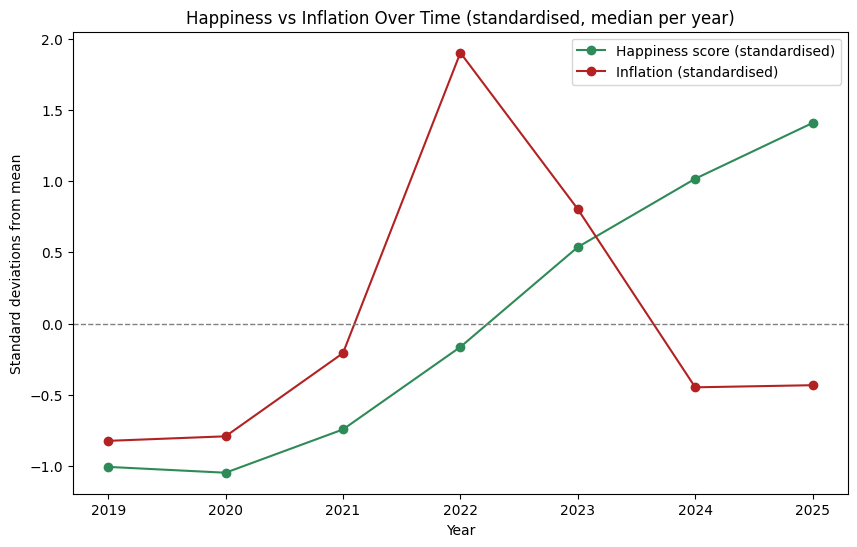

In [102]:
yearly_trends_median = combined.groupby('report_year')[['happiness_score', 'inflation']].median()

def to_zscore(series):
    return (series - series.mean()) / series.std()

standardised = yearly_trends_median.copy()
standardised['happiness_score'] = to_zscore(standardised['happiness_score'])
standardised['inflation'] = to_zscore(standardised['inflation'])

plt.figure(figsize=(10, 6))
plt.plot(standardised.index, standardised['happiness_score'], color='seagreen', marker='o', label='Happiness score (standardised)')
plt.plot(standardised.index, standardised['inflation'], color='firebrick', marker='o', label='Inflation (standardised)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Standard deviations from mean')
plt.xlabel('Year')
plt.title('Happiness vs Inflation Over Time (standardised, median per year)')
plt.legend()
plt.show()

Median happiness and median inflation are plotted on a shared standardised (z-score) scale rather than two separate y-axes - a single axis keeps the comparison true instead of implying a relationship that's really just two arbitrary scales lining up.

The two series look largely unrelated in the same year. That's plausible: inflation's effect on wellbeing is more likely to **lag** - people feel the squeeze on their finances well after prices actually rise - so a same-year comparison may simply be too early to catch it.

## Summary of Key Insights

**GDP per capita is the strongest financial predictor of happiness.** Correlation of 0.68 with happiness score — notably stronger than inflation (-0.23), unemployment (-0.22), or the Gini index (-0.20), all of which showed only weak relationships. The GDP/happiness relationship also isn't linear: happiness rises sharply with GDP up to roughly $10k per capita, then plateaus — beyond that point, additional wealth buys comparatively little extra reported happiness.

**Hong Kong is a clear, explainable outlier.** Despite GDP per capita in the $46k–$57k range (where most countries score 7+ on happiness), Hong Kong consistently scored only 5.3–5.7 across all seven years — plausibly linked to the 2019-2020 political unrest, the national security law, and strict COVID policies over this period.

**Regional wealth doesn't translate to happiness equally.** North and South America both report higher happiness than their GDP alone would predict, while Asia reports lower happiness than its GDP would predict — suggesting non-financial, likely cultural or social factors, meaningfully shape happiness independent of income.

**Global happiness followed its own steady upward trend, largely independent of the 2021–2023 global inflation spike.** Standardising both series (to correct for their very different scales and starting baselines) showed happiness rising near-linearly across 2019–2025 with no visible dip during the inflation peak — suggesting inflation's effect on wellbeing, if any, may be delayed rather than immediate, or too small to detect at a global aggregate level.

**Some expected relationships didn't hold, and some unexpected ones appeared.** Unemployment showed only a weak link to social support (contrary to the assumption that job loss erodes community connectedness), while generosity showed a weak negative relationship with GDP (wealthier countries perceived as slightly less generous) but a more expected negative relationship with unemployment (less capacity to give during economic hardship). Corruption and inequality (Gini) also didn't correlate as strongly as expected — possibly because perceived corruption is a qualitative measure that doesn't always show up in quantitative inequality statistics.

**Limitations:** Gini index data was sparse (many countries don't measure inequality annually) and was left with its natural gaps rather than interpolated. The regional and time-trend analyses are based on a small number of aggregate data points (6 regions, 7 years), so should be read as suggestive patterns rather than statistically robust conclusions.